**WORKING WITH API'S**

Note: for the following section to work the Jobs_API.ipynb must be functioning at the same time

In [29]:
import requests # you need this module to make an API call
import pandas as pd
!pip install openpyxl
import matplotlib.pyplot as plt

In [30]:
api_url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

def get_number_of_jobs_T(technology):
    api_url = "http://127.0.0.1:5000/data"
    payload = {"Key Skills": technology}
    response = requests.get(api_url, params=payload)
    if response.ok:
        data = response.json()
        number_of_jobs = len(data)
    else:
        number_of_jobs = 0
    return technology, number_of_jobs


In [31]:
get_number_of_jobs_T("Python")

('Python', 1173)

In [32]:
def get_number_of_jobs_L(location):
    api_url = "http://127.0.0.1:5000/data"
    payload = {"Location": location}
    response = requests.get(api_url, params=payload)
    if response.ok:
        data = response.json()
        number_of_jobs = len(data)
    else:
        number_of_jobs = 0
    return location, number_of_jobs

In [33]:
get_number_of_jobs_L('Los Angeles')

('Los Angeles', 640)

In [34]:
import openpyxl

location_list = ["Los Angeles", "New York", "San Francisco",
                  "Washington DC", "Seattle", "Austin", "Detroit"]

tech_list = ["C", "C#", "C++", "Java", "JavaScript", "Python", "Scala",
             "Oracle", "SQL Server", "MySQL Server", "PostgreSQL", "MongoDB"]

wb = openpyxl.Workbook()

# First sheet: rename the default active sheet instead of leaving it blank
ws_loc = wb.active
ws_loc.title = "Location_Jobs"
ws_loc.append(["Location", "Number of Jobs"])
for loc in location_list:
    location, number_of_jobs = get_number_of_jobs_L(loc)
    ws_loc.append([location, number_of_jobs])

# Second sheet: create a new one for technologies
ws_tech = wb.create_sheet("Technology_Jobs")
ws_tech.append(["Technology", "Number of Jobs"])
for tech in tech_list:
    technology, number_of_jobs = get_number_of_jobs_T(tech)
    ws_tech.append([technology, number_of_jobs])

wb.save("job-postings.xlsx")

In [35]:
df

,Location,Number of Jobs
5,Austin,434
2,San Francisco,435
0,Los Angeles,640
1,New York,3226
4,Seattle,3375
6,Detroit,3945
3,Washington DC,5316


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Austin'),
  Text(1, 0, 'San Francisco'),
  Text(2, 0, 'Los Angeles'),
  Text(3, 0, 'New York'),
  Text(4, 0, 'Seattle'),
  Text(5, 0, 'Detroit'),
  Text(6, 0, 'Washington DC')])

<Figure size 800x500 with 0 Axes>

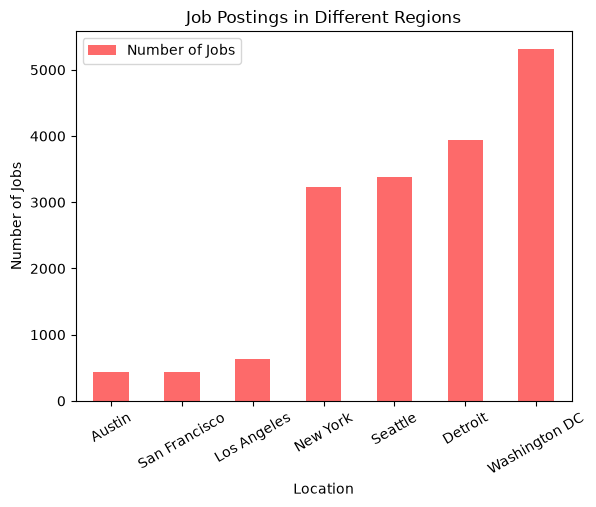

In [66]:
df = pd.read_excel('job-postings.xlsx')

df = df.sort_values(by='Number of Jobs')

plt.figure(figsize=[8,5])
df.plot(kind='bar', x='Location', y='Number of Jobs', color="#FC1B1BA6")
plt.title('Job Postings in Different Regions')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30)

**Collecting Data Using Web Scraping Method**

In [45]:
from bs4 import BeautifulSoup

In [46]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

data = requests.get(url).text

soup = BeautifulSoup(data,"html.parser")

table = soup.find('table')

Programming_Language = []
Avg_Salary = []

for row in table.find_all('tr'):
    cols = row.find_all('td')
    Programming_Language.append(cols[1].getText())
    Avg_Salary.append(cols[3].getText()) 

df = pd.DataFrame({
    'Language': Programming_Language,
    'Average Annual Salary': Avg_Salary
})
df.columns = df.iloc[0]      # grab row 0 and use it as the column headers
df = df[1:]  

df

df.to_csv('popular-languages.csv')


Text(0.5, 1.0, 'Average Annual Salary for Popular Programming Languages')

<Figure size 800x500 with 0 Axes>

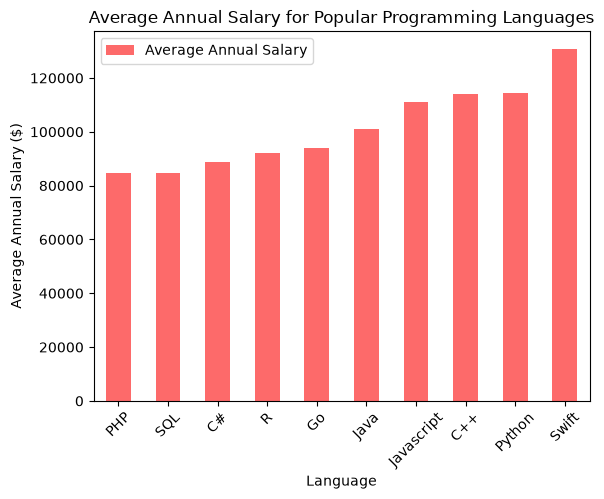

In [65]:
df = pd.read_csv('popular-languages.csv')
df['Average Annual Salary'] = df['Average Annual Salary'].replace(r"[$,]","", regex=True).astype('int')
df = df.sort_values(by='Average Annual Salary')

plt.figure(figsize=[8,5])
df.plot(kind='bar', x = 'Language', y = 'Average Annual Salary', color="#FC1B1BA6")
plt.xticks(rotation=45)
plt.ylabel('Average Annual Salary ($)')
plt.title('Average Annual Salary for Popular Programming Languages')

**EXTENSIVE STACK OVERFLOW DEVELOPER SURVEY DATABASE**

In [39]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"

survey_df = pd.read_csv(file_path)

print('number of rows and columns are:', survey_df.shape)

number of rows and columns are: (65457, 114)


In [40]:
survey_df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [41]:


age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

# Create a new numeric Age column
survey_df['Age_numeric'] = survey_df['Age'].map(age_mapping)

Avg_age = survey_df['Age_numeric'].mean()

Avg_age

np.float64(32.68101635065633)

In [42]:
country_df = pd.DataFrame(survey_df['Country'].value_counts())
country_df

,count
Country,
United States of America,11099
Germany,4949
India,4232
United Kingdom of Great Britain and Northern Ireland,3227
Ukraine,2672
...,...
Haiti,1
Nauru,1
Chad,1
